# **Radar meteorológico - aplicações com Python**



###**Montagem do Drive**

Para montar o Drive, utiliza-se as linhas de comando abaixo ou pode-se fazer o processo manualmente na barra de ferramentas do lado esquerdo: Arquivos > Montar Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Plan Position Indicator** **(PPI)**




### **1) Instalando as bibliotecas adicionais**



In [ ]:
!apt-get install libproj-dev proj-data proj-bin
!apt-get install libgeos-dev
!pip install --no-binary shapely shapely --force
!pip install cartopy                    # biblioteca para projeção de mapas
print('\n')

!pip install proplot==0.6.4             # biblioteca para gerar mapas - tem a dependência do cartopy
print('\n')

!pip install numpy --upgrade

!pip install arm_pyart                  # biblioteca para trabalhar com dados de radar
print('\n')

Reading package lists... Done
Building dependency tree       
Reading state information... Done
libproj-dev is already the newest version (7.2.1-1~focal0).
proj-bin is already the newest version (7.2.1-1~focal0).
proj-data is already the newest version (7.2.1-1~focal0).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.
Reading package lists... Done
Building dependency tree       
Reading state information... Done
libgeos-dev is already the newest version (3.9.1-1~focal0).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Using cached shapely-2.0.1-cp310-cp310-linux_x86_64.whl
  Using cached numpy-1.24.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.3
    Uninstalling numpy-1.24.3:
      Successfully uninstalled numpy-1.24.3
  Attempting uninstall: shapely
    Foun

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Using cached Cartopy-0.21.1.tar.gz (10.9 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 51.9 MB/s eta 0:00:00
  Created wheel for cartopy: filename=Cartopy-0.21.1-cp310-cp310-linux_x86_64.whl size=11102728 sha256=bb87b462148120bf762196965402ca58215a74e43587168e4583c698475ed2b1
  Stored in directory: /root/.cache/pip/wheels/30/b0/1a/1c1909e00c76653dc4e2ff48555257c0eb2d1698280c8d9955
Successfully built cartopy


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/




### **2) Importando as bibliotecas**

In [ ]:
import pyart                            # biblioteca para trabalhar com dados de radar
import matplotlib.pyplot as plt         # biblioteca para gerar gráficos
import cartopy.crs as ccrs              # biblioteca para trabalhar com projeções de mapas
from netCDF4 import num2date            # biblioteca para trabalhar com datas
import numpy as np                      # biblioteca para trabalhar com matrizes
import glob                             # biblioteca para monsta lista de arquivos
from tqdm.notebook import tqdm_notebook # biblioteca que gera barra de progresso
import os                               # biblioteca para trabalhar com o sistema operacional
import numpy.ma as ma

import warnings
warnings.filterwarnings("ignore")


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



### **3) Leitura dos dados de radar**

Os dados volumétricos são dados brutos. Os radares do CEMADEN tem dados volumétricos no formato HDF5. *Hierarquical Data Format* é um tipo de dado em código aberto, comumente usado na meteorologia, para organização e armazenamento de um grande volume de dados.

Para a leitura desse tipo de dado, o [Py-ART](https://arm-doe.github.io/pyart/API/index.html) é a biblioteca adequada.

Com as funções auxiliares ([pyart_aux.io](https://arm-doe.github.io/pyart/API/generated/pyart.aux_io.html)), é possível fazer a leitura e escrita de formatos de arquivos de radar.

No caso de radares do Cemaden, a subrotina [pyart.aux_io.read_sinarame_h5](https://arm-doe.github.io/pyart/API/generated/pyart.aux_io.read_sinarame_h5.html#pyart.aux_io.read_sinarame_h5) é utilizada para ler os dados.

In [ ]:
dir = '/content/drive/MyDrive/METEOROLOGIA_POR_SATÉLITES/NATAL_29052023/'
filename = '2023052901300400dBZ.vol.h5'                      # nome do arquivo (YYYYmmddHHMMSS00dBZ.vol.h5)

In [ ]:
radar = pyart.aux_io.read_sinarame_h5('/content/2023053110074700dBZ.vol.h5')    # esse comando funciona para os radares do Cemaden, para os radares do DECEA,
                                                             # usar: pyart.aux_io.read_gamic(formato HDF-Gamic)
radar                                                        # "radar" é um objeto do Py-ART

In [ ]:
print(radar.fields.keys())                                   # exibe os campos do objeto "radar"

dict_keys(['reflectivity'])


#### **1.   Bins**





In [ ]:
radar.range.keys()

In [ ]:
radar.range

#### **2.   Tempo do *volscan***


In [ ]:
print('Data da imagem do radar=', pyart.util.datetime_from_grid(radar))
print('Unidades do tempo=', radar.time['units'])
print('Início do volcan=', num2date(radar.time['data'][0], radar.time['units'] ))
print('Fim do volcan=', num2date(radar.time['data'][-1], radar.time['units'] ))



#### **3.   Azimutes**

In [ ]:
radar.azimuth.keys()

In [ ]:
radar.azimuth                                                # "azimuth" é um dicionário

In [ ]:
radar.azimuth['units']                                       # unidade do azimute

In [1]:
radar.azimuth['data']                                        # valores ("data") do azimute

NameError: name 'radar' is not defined

In [ ]:
print('Total de azimutes=', np.shape(radar.azimuth['data'])) # o formato do azimute (o total)


#### **4.   Elevações**



In [ ]:
radar.sweep_start_ray_index                                  # sweep é um dicionário
radar.fixed_angle                                            # fixed_angle é um dicionário e são os ângulos de elevações
radar.fixed_angle['units']

In [ ]:
print('Quantidade de elevações=', np.shape(radar.sweep_start_ray_index['data'])) # total de elevações
print('Ângulos de elevação(graus)=', radar.fixed_angle['data'])

#### **5.   Latitude, longitude e altura**



In [ ]:
radar.latitude.keys()

In [ ]:
radar.latitude              # latitude é um dicionário

In [ ]:
radar.latitude['long_name'] # mostra o valor da chave "long_name"

In [ ]:
radar.longitude

In [ ]:
# "data" é um array, portanto precisamos indicar qual posição queremos.
# No caso queremos a primeira, porém ele só possui um valor.
print('Latitude (graus)=', radar.latitude['data'][0])
print('Longitude (graus)=', radar.longitude['data'][0])
print('Altura (m)=', radar.altitude['data'][0])

In [ ]:
# Infos dos dados (ex.: reflectivity)
print('Máxima refletividade=', radar.fields['reflectivity']['data'].max())
print('Minima refletividade=', radar.fields['reflectivity']['data'].min())

max_indices = ma.where(radar.fields['reflectivity']['data'] == ma.max(radar.fields['reflectivity']['data']))
# o resultado é algo como: (array([99]), array([53])),
# o que significa que o máximo de refletividade
# está no azimute 99 e no bin 53
min_indices = ma.where(radar.fields['reflectivity']['data'] == ma.min(radar.fields['reflectivity']['data']))

####**6.   Informações dos dados**

In [ ]:
radar.fields['reflectivity']['data']

masked_array(
  data=[[--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        ...,
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --]],
  mask=[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],
  fill_value=1e+20,
  dtype=float32)

In [ ]:
type(radar.fields['reflectivity']['data']) # numpy.ma.core.MaskedArray

numpy.ma.core.MaskedArray

In [ ]:
np.shape(radar.fields['reflectivity']['data']) # matriz 2-D 4200azimutesx960bins

(4680, 1000)

In [ ]:
print('Dimensão dos dados de refletividade=', np.shape(radar.fields['reflectivity']['data']))
print('Unidade de refletividade=', radar.fields['reflectivity']['units'])

Dimensão dos dados de refletividade= (4680, 1000)
Unidade de refletividade= dBZ


In [ ]:
print('Máxima refletividade=', radar.fields['reflectivity']['data'].max())
print('Minima refletividade=', radar.fields['reflectivity']['data'].min())

Máxima refletividade= 55.0
Minima refletividade= -31.5


In [ ]:
max_indices = ma.where(radar.fields['reflectivity']['data'] == ma.max(radar.fields['reflectivity']['data']))
# o resultado é algo como: (array([99]), array([53])),
# o que significa que o máximo de refletividade
# está no azimute 99 e no bin 53

min_indices = ma.where(radar.fields['reflectivity']['data'] == ma.min(radar.fields['reflectivity']['data']))

### **4) Plota PPI**

O Py-ART auxilia na plotagem dos dados de PPI com a disponibilização de várias funções.

Inicialmente, vamos definir uma função que calcule as latitudes e longitudes mínimas e máximas (inferior/superior e esquerda/direita).

In [ ]:
import geopy
from geopy import distance

In [ ]:
# Função que calcula as latitudes inferior/superior e longitudes esquerda/direita
# dos limites da imagem de um radar

def calc_latlon_from_distance_radar(lat_central, lon_central, distancia):

    """
    Função que calcula as latitudes e longitudes mínimas e máxima da imagem de um radar

    Parâmetros:
                lat_central (float): latitude em graus do ponto central
                lon_central (float): longitude em graus do ponto central
                distância (float): distância em km

    Retorna:
             minlat (float): latitude miníma em graus do ponto 2
             maxlat (float): latitude máxima em graus do ponto 2
             minlon (float): longitude miníma em graus do ponto 2
             maxlon (float): longitude máxima em graus do ponto 2
    """

    # define azimute
    azimutes = [0, 90, 180, 270]

    # given: lat1, lon1, b = bearing in degrees e d = distance in kilometers
    origin = geopy.Point(lat_central, lon_central)

    # calcula latitude e longitude do ponto 2
    for azimute in azimutes:
        destination = distance.distance(kilometers=distancia).destination(origin, azimute)
        lat2, lon2 = destination.latitude, destination.longitude

        if azimute == 0: maxlat = lat2

        if azimute == 90: maxlon = lon2

        if azimute == 180: minlat = lat2

        if azimute == 270: minlon = lon2

    return minlat, maxlat, minlon, maxlon

Agora, extrai a latitude e a longitude do radar. Em seguida, calculamos a latmin, latmax, lonmin e lonmax da área da figura.

In [ ]:
lat_radar, lon_radar = radar.latitude['data'][0], radar.longitude['data'][0]

latmin, latmax, lonmin, lonmax = calc_latlon_from_distance_radar(lat_radar, lon_radar, 400)

Plot:

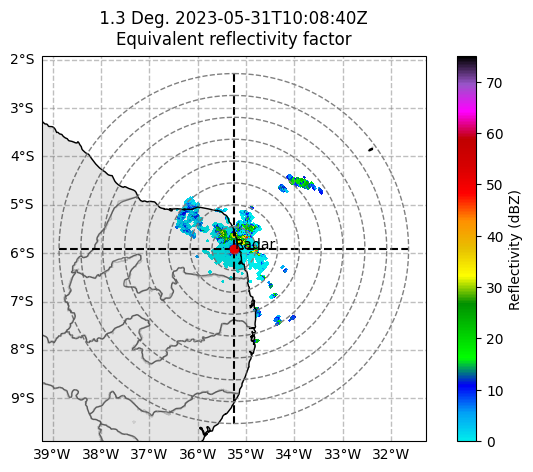

In [ ]:
# define a elevação
level = 2

# extrai o ângulo de elevação da primeira elevação (level=0)
str_level = str(radar.fixed_angle["data"][level])

# cria o display
display = pyart.graph.RadarMapDisplay(radar)

# setting projection
projection = ccrs.PlateCarree(central_longitude=lon_radar)

# cria moldura da figura
fig = plt.figure(figsize=[8,5])

# plota o mapa
display.plot_ppi_map('reflectivity', sweep=level, vmin=0, vmax=75,
                     fig=fig, lat_0=lat_radar, lon_0=lon_radar,
                     projection=projection,
                     resolution='10m',
                     cmap='pyart_NWSRef', colorbar_label='Reflectivity (dBZ)', shapefile='/content/drive/MyDrive/BR_UF_2022/BR_UF_2022',
                     shapefile_kwargs= {'color': 'black', 'alpha': 0.1,  'zorder': 3, 'edgecolor': 'black'},
                     mask_outside=False)

# cross hairs
display.plot_line_geo(np.array([lon_radar, lon_radar]), np.array([latmin, latmax]), linestyle='--', color='black')
display.plot_line_geo(np.array([lonmin, lonmax]), np.array([lat_radar, lat_radar]), linestyle='--', color='black')

# plota aneis de distância
display.plot_range_rings([50, 100, 150, 200, 250, 300, 350, 400], ls='--', lw=1, col='gray')

# indicate the radar location with a point
display.plot_point(lon_radar, lat_radar, symbol='o', label_text='Radar', color='red')

# plota as linhas de latitude e longitudes
ax = plt.gca()
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False

In [ ]:
files = sorted(glob.glob(f'{dir}*dBZ.vol.h5'))
print(files)

In [ ]:
for file in tqdm_notebook(files):

    print('....PROCESSANDO--->>>>', file)

    # extrai o nome do arquivo
    filename = os.path.basename(os.path.splitext(file)[0])

    # leitura do arquivo
    dados = pyart.aux_io.read_sinarame_h5(file)

    # extrai a data da imagem do radar
    data = pyart.util.datetime_from_grid(dados)

    # extrai o ângulo de elevação da primeira elevação (level=0)
    str_level = str(dados.fixed_angle["data"][level])

    # extrai a latitude e longitude do radar
    lat_radar, lon_radar = dados.latitude['data'][0], dados.longitude['data'][0]

    # cria o display
    display = pyart.graph.RadarMapDisplay(dados)

    # setting projection
    projection = ccrs.PlateCarree(central_longitude=lon_radar)

    # cria moldura da figura
    fig = plt.figure(figsize=[8,5])

    # plota o mapa
    display.plot_ppi_map('reflectivity', sweep=level, vmin=0, vmax=75,
                     fig=fig, lat_0=lat_radar, lon_0=lon_radar,
                     projection=projection,
                     resolution='10m',
                     cmap='pyart_NWSRef', colorbar_label='Reflectivity (dBZ)', shapefile='/content/drive/MyDrive/BR_UF_2022/BR_UF_2022',
                     shapefile_kwargs= {'color': 'black', 'alpha': 0.3, 'zorder': 3, 'edgecolor': 'black'},
                     mask_outside=True)

    # cross hairs
    display.plot_line_geo(np.array([lon_radar, lon_radar]), np.array([latmin, latmax]), linestyle='--', color='black')
    display.plot_line_geo(np.array([lonmin, lonmax]), np.array([lat_radar, lat_radar]), linestyle='--', color='black')

    # plota aneis de distância
    display.plot_range_rings([50, 100, 150, 200, 250], ls='--', lw=1, col='gray')

    # indicate the radar location with a point
    display.plot_point(lon_radar, lat_radar, symbol='o', label_text='Radar', color='red')

    # get the current axes and plot some lat and lon lines
    ax = plt.gca()
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
    gl.xlabels_top = False
    gl.ylabels_right = False
